In [23]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5, random_state=42, stratify=y_temp)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1078, 64)
(359, 64)
(360, 64)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [26]:
import numpy as np

def one_hot(y, num_classes=10):
    y_onehot = np.zeros((len(y), num_classes))
    y_onehot[np.arange(len(y)), y] = 1
    return y_onehot

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy(pred, y_true):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(pred + 1e-8)) / m

def accuracy(model, X, y):
    probs = model.forward(X, train=False)
    pred = np.argmax(probs, axis=1)
    return np.mean(pred == y)

In [27]:
class Dropout:

    def __init__(self, p):
        self.p = p
        self.mask = None
        self.train_mode = True

    def forward(self, x):

        if not self.train_mode or self.p == 0:
            return x

        self.mask = (np.random.rand(*x.shape) > self.p) / (1 - self.p)

        return x * self.mask

    def backward(self, grad):

        if not self.train_mode or self.p == 0:
            return grad

        return grad * self.mask

In [28]:
class MLP:

    def __init__(self, D=64, H=128, C=10, dropout_p=0):

        self.W1 = np.random.randn(D, H) * 0.01
        self.b1 = np.zeros((1, H))

        self.W2 = np.random.randn(H, C) * 0.01
        self.b2 = np.zeros((1, C))

        self.dropout = Dropout(dropout_p)

    def forward(self, X, train=True):

        self.dropout.train_mode = train

        self.X = X

        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)  # ReLU

        self.a1 = self.dropout.forward(self.a1)

        self.z2 = self.a1 @ self.W2 + self.b2

        self.probs = softmax(self.z2)

        return self.probs

    def backward(self, y_true):

        m = y_true.shape[0]

        dz2 = (self.probs - y_true) / m

        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T

        da1 = self.dropout.backward(da1)

        dz1 = da1 * (self.z1 > 0)

        dW1 = self.X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        grads = {
            "W1": dW1,
            "b1": db1,
            "W2": dW2,
            "b2": db2
        }

        return grads

In [29]:
class SGD_Momentum:

    def __init__(self, params, lr=0.05, gamma=0.9):

        self.lr = lr
        self.gamma = gamma

        self.v = {}
        for k in params:
            self.v[k] = np.zeros_like(params[k])

    def step(self, params, grads):

        for k in params:

            self.v[k] = self.gamma * self.v[k] - self.lr * grads[k]

            params[k] += self.v[k]

In [30]:
def train_model(model, optimizer, X_train, y_train, X_val, y_val, epochs=100):

    y_train_oh = one_hot(y_train)

    losses = []
    val_accs = []

    for epoch in range(epochs):

        probs = model.forward(X_train, train=True)

        loss = cross_entropy(probs, y_train_oh)

        grads = model.backward(y_train_oh)

        params = {
            "W1": model.W1,
            "b1": model.b1,
            "W2": model.W2,
            "b2": model.b2
        }

        optimizer.step(params, grads)

        val_acc = accuracy(model, X_val, y_val)

        losses.append(loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: loss={loss:.4f}, val_acc={val_acc:.4f}")

    return losses, val_accs

In [31]:
model_A = MLP(dropout_p=0)

optimizer_A = SGD_Momentum(
    {"W1": model_A.W1, "b1": model_A.b1, "W2": model_A.W2, "b2": model_A.b2},
    lr=0.05,
    gamma=0
)

loss_A, acc_A = train_model(model_A, optimizer_A,
                            X_train, y_train,
                            X_val, y_val)

Epoch 1: loss=2.3019, val_acc=0.1365
Epoch 2: loss=2.3012, val_acc=0.1643
Epoch 3: loss=2.3004, val_acc=0.1894
Epoch 4: loss=2.2996, val_acc=0.2368
Epoch 5: loss=2.2989, val_acc=0.2730
Epoch 6: loss=2.2981, val_acc=0.3092
Epoch 7: loss=2.2973, val_acc=0.3510
Epoch 8: loss=2.2965, val_acc=0.3872
Epoch 9: loss=2.2957, val_acc=0.4150
Epoch 10: loss=2.2949, val_acc=0.4429
Epoch 11: loss=2.2941, val_acc=0.4986
Epoch 12: loss=2.2932, val_acc=0.5237
Epoch 13: loss=2.2924, val_acc=0.5571
Epoch 14: loss=2.2915, val_acc=0.5794
Epoch 15: loss=2.2906, val_acc=0.6072
Epoch 16: loss=2.2897, val_acc=0.6184
Epoch 17: loss=2.2888, val_acc=0.6295
Epoch 18: loss=2.2879, val_acc=0.6351
Epoch 19: loss=2.2869, val_acc=0.6518
Epoch 20: loss=2.2859, val_acc=0.6546
Epoch 21: loss=2.2849, val_acc=0.6630
Epoch 22: loss=2.2839, val_acc=0.6685
Epoch 23: loss=2.2828, val_acc=0.6713
Epoch 24: loss=2.2817, val_acc=0.6797
Epoch 25: loss=2.2806, val_acc=0.6880
Epoch 26: loss=2.2794, val_acc=0.6992
Epoch 27: loss=2.2782

In [32]:
model_B = MLP(dropout_p=0.5)

optimizer_B = SGD_Momentum(
    {"W1": model_B.W1, "b1": model_B.b1, "W2": model_B.W2, "b2": model_B.b2},
    lr=0.05,
    gamma=0.9
)

loss_B, acc_B = train_model(model_B, optimizer_B,
                            X_train, y_train,
                            X_val, y_val)

Epoch 1: loss=2.3031, val_acc=0.0975
Epoch 2: loss=2.3019, val_acc=0.1588
Epoch 3: loss=2.3010, val_acc=0.2563
Epoch 4: loss=2.2991, val_acc=0.3621
Epoch 5: loss=2.2967, val_acc=0.4763
Epoch 6: loss=2.2942, val_acc=0.5655
Epoch 7: loss=2.2903, val_acc=0.6435
Epoch 8: loss=2.2866, val_acc=0.6713
Epoch 9: loss=2.2820, val_acc=0.6825
Epoch 10: loss=2.2774, val_acc=0.6964
Epoch 11: loss=2.2716, val_acc=0.7075
Epoch 12: loss=2.2643, val_acc=0.7047
Epoch 13: loss=2.2562, val_acc=0.7103
Epoch 14: loss=2.2459, val_acc=0.7075
Epoch 15: loss=2.2341, val_acc=0.7047
Epoch 16: loss=2.2197, val_acc=0.6964
Epoch 17: loss=2.2039, val_acc=0.6936
Epoch 18: loss=2.1823, val_acc=0.6908
Epoch 19: loss=2.1581, val_acc=0.6880
Epoch 20: loss=2.1242, val_acc=0.6825
Epoch 21: loss=2.0870, val_acc=0.6769
Epoch 22: loss=2.0445, val_acc=0.6797
Epoch 23: loss=1.9911, val_acc=0.6741
Epoch 24: loss=1.9356, val_acc=0.6769
Epoch 25: loss=1.8653, val_acc=0.6741
Epoch 26: loss=1.7901, val_acc=0.6769
Epoch 27: loss=1.7113

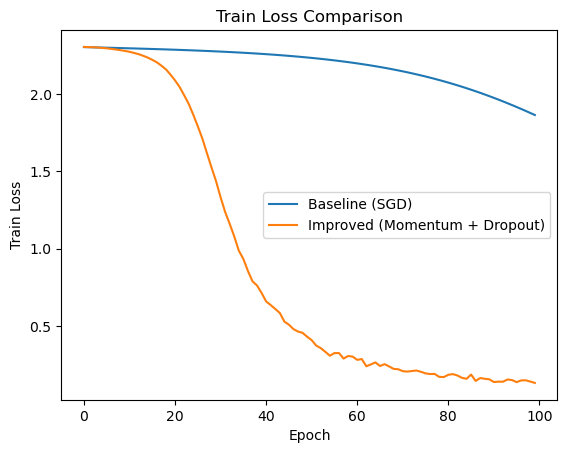

In [33]:
import matplotlib.pyplot as plt
import os

plt.plot(loss_A, label="Baseline (SGD)")
plt.plot(loss_B, label="Improved (Momentum + Dropout)")

plt.xlabel("Epoch")
plt.ylabel("Train Loss")

plt.legend()
plt.title("Train Loss Comparison")

os.makedirs(os.path.join("resources", "pics"), exist_ok=True)
plot_path = os.path.join("resources", "pics", "lab4.png")
plt.savefig(plot_path, dpi=150)

plt.show()